In [4]:
import scanpy as sc
import pandas as pd
import numpy as np
import anndata
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde
from diptest import diptest
from binning import *

In [2]:
"""
We assume that the spot coordinates (avaiable with the datasets) are in um unit.
"""

'\nWe assume that the spot coordinates (avaiable with the datasets) are in um unit.\n'

### Merfish brain

In [5]:
path = "/data/Ajita/Spatial/Datasets/Spatial_Deconvolution/_Image_Binned_datasets/MERFISH_Mouse_Hypothalamic_preoptic_region/ST/"

unbinned_st_path = path + "unbinned_ST/SC_spot_coords.h5ad"

binned_path = path + "ST_55_python.h5ad"

In [3]:



celltype_col = "Cell_class_NEW"
spot_diameter = 55 #55 # 550 -> 510 # 100->6, 9, etc.
dataset = "merfish_brain"
coord1 = 0
coord2 = 1

combined_adata = binning(unbinned_st_path, spot_diameter, celltype_col, dataset, coord1, coord2)
print (combined_adata)

merfish_brain
Number of spots in mask: 2
Number of spots in mask: 3
Number of spots in mask: 10
Number of spots in mask: 5
Number of spots in mask: 5
Number of spots in mask: 7
Number of spots in mask: 6
Number of spots in mask: 7
Number of spots in mask: 4
Number of spots in mask: 6
Number of spots in mask: 5
Number of spots in mask: 3
Number of spots in mask: 5
Number of spots in mask: 8
Number of spots in mask: 7
Number of spots in mask: 1
Number of spots in mask: 2
Number of spots in mask: 3
Number of spots in mask: 5
Number of spots in mask: 12
Number of spots in mask: 5
Number of spots in mask: 9
Number of spots in mask: 5
Number of spots in mask: 7
Number of spots in mask: 6
Number of spots in mask: 1
Number of spots in mask: 5
Number of spots in mask: 3
Number of spots in mask: 2
Number of spots in mask: 5
Number of spots in mask: 7
Number of spots in mask: 5
Number of spots in mask: 3
Number of spots in mask: 5
Number of spots in mask: 1
Number of spots in mask: 2
Number of sp

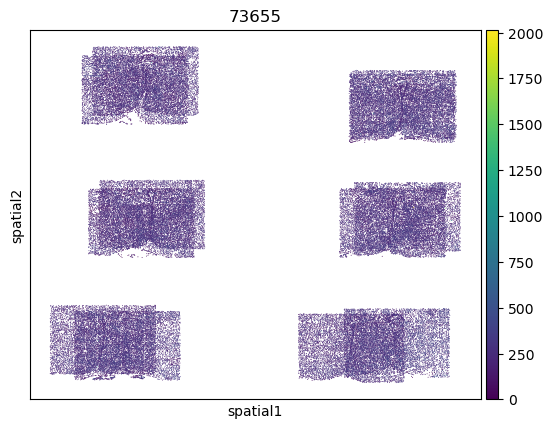

In [4]:
st_adata = sc.read_h5ad(unbinned_st_path)
st_adata.obsm["spatial"] = st_adata.obsm["spatial"].to_numpy()
st_adata.obs["umi_count"] = st_adata.X.sum(axis = 1)
sc.pl.embedding(st_adata, basis = "spatial", color = "umi_count", title = st_adata.shape)

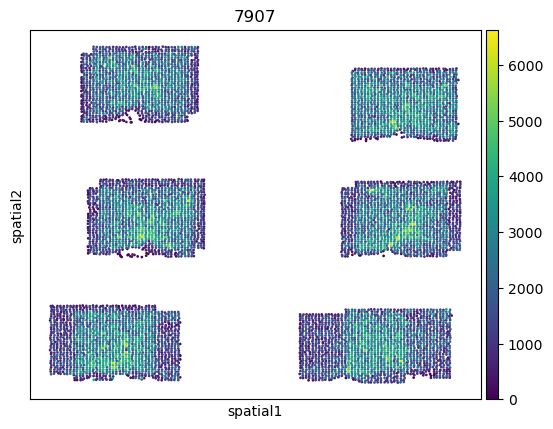

In [5]:
combined_adata.obs["umi_count"] = combined_adata.X.sum(axis = 1)
sc.pl.embedding(combined_adata, basis = "spatial", color = "umi_count", title = combined_adata.shape)

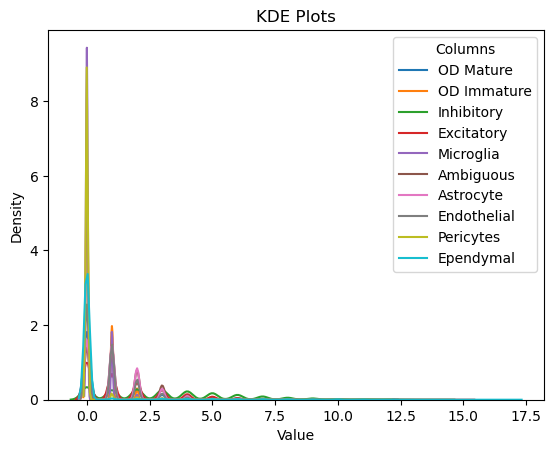

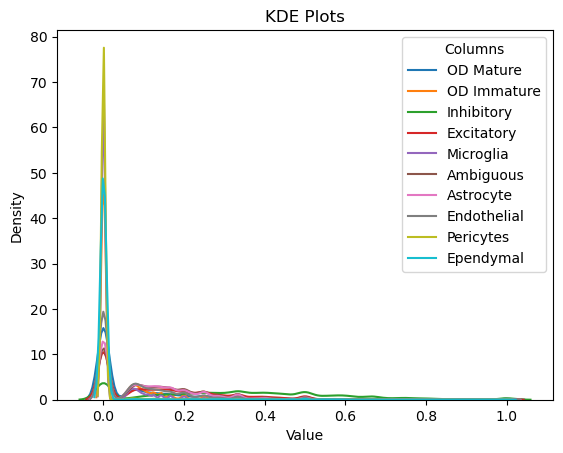

In [6]:
dt = combined_adata.obs
dt = dt[dt.columns[:-2]]
dt_ = dt.div(dt.sum(axis=1),axis=0)
diptest(dt)
diptest(dt_)

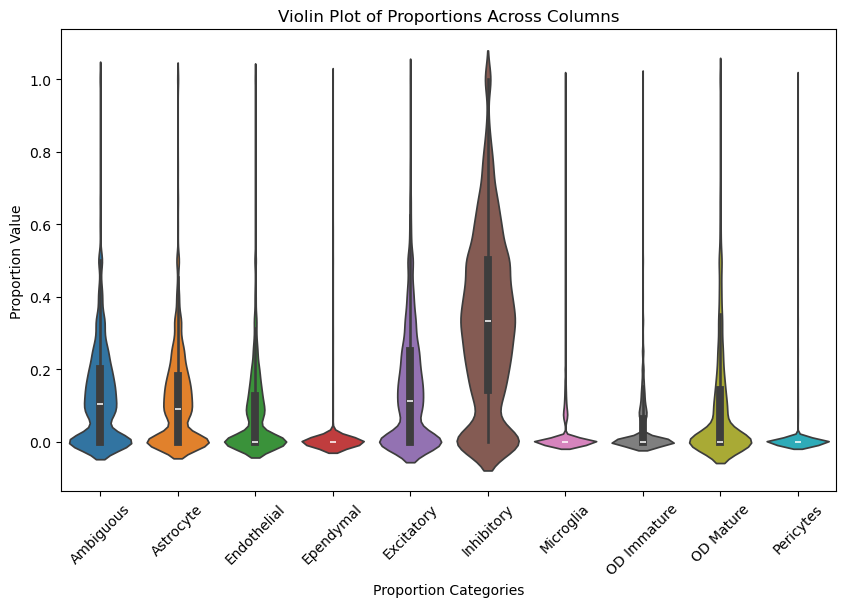

In [7]:
dt_ = dt_.sort_index(axis=1)

# Violin plot for more detailed distribution visualization
plt.figure(figsize=(10, 6))
sns.violinplot(data=dt_)
plt.title('Violin Plot of Proportions Across Columns')
plt.ylabel('Proportion Value')
plt.xlabel('Proportion Categories')
plt.xticks(rotation=45) #after creating the plot. Here's how you can adjust the code:
plt.show()

(array([140., 201.,   0., 345.,   0., 492., 575.,   0., 617.,   0., 632.,
        625.,   0., 580.,   0., 576., 549.,   0., 605.,   0., 558., 412.,
          0., 338.,   0., 252., 170.,   0., 115.,   0.,  50.,  38.,   0.,
         17.,   0.,  10.,   7.,   0.,   1.,   2.]),
 array([ 1. ,  1.6,  2.2,  2.8,  3.4,  4. ,  4.6,  5.2,  5.8,  6.4,  7. ,
         7.6,  8.2,  8.8,  9.4, 10. , 10.6, 11.2, 11.8, 12.4, 13. , 13.6,
        14.2, 14.8, 15.4, 16. , 16.6, 17.2, 17.8, 18.4, 19. , 19.6, 20.2,
        20.8, 21.4, 22. , 22.6, 23.2, 23.8, 24.4, 25. ]),
 <BarContainer object of 40 artists>)

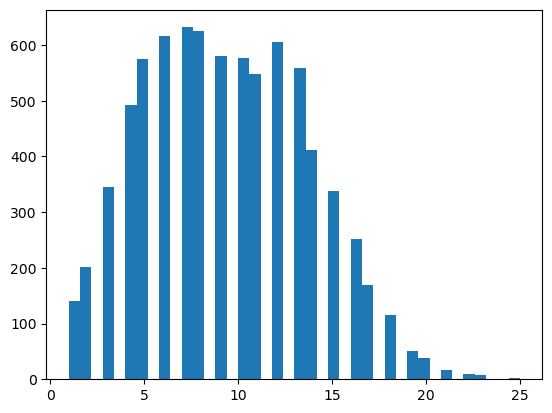

In [8]:
a = dt.sum(axis = 1)
plt.hist(a, bins='auto')

In [9]:

no_of_cells = dt.sum(axis = 1)
no_of_cells.to_csv(path + "no_of_cells.csv")

res_path = "/data/Ajita/Spatial/Datasets/Spatial_Deconvolution/_Image_Binned_datasets/MERFISH_Mouse_Hypothalamic_preoptic_region/final_outputs_repo/gt.h5ad"

columns = combined_adata.obs.columns.tolist()[:-2]
loc = combined_adata.obsm["spatial"]#.to_numpy()
columns.sort()

ann_test = anndata.AnnData(dt_.to_numpy())
ann_test.obsm["Average_STAGATE_ReX"] = dt_.to_numpy()
ann_test.var_names = columns
ann_test.obsm["spatial"] = loc

print (ann_test)    
ann_test.write_h5ad(res_path)  


AnnData object with n_obs × n_vars = 7907 × 10
    obsm: 'Average_STAGATE_ReX', 'spatial'


In [16]:
combined_adata.var_names = st_adata.var_names
combined_adata.obs_names = [str(i) for i in range(len(combined_adata))]
print (combined_adata.obs_names, combined_adata.var_names)
combined_adata.write_h5ad(binned_path)

Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9',
       ...
       '7897', '7898', '7899', '7900', '7901', '7902', '7903', '7904', '7905',
       '7906'],
      dtype='object', length=7907) Index(['Ace2', 'Adora2a', 'Aldh1l1', 'Amigo2', 'Ano3', 'Aqp4', 'Ar',
       'Arhgap36', 'Avpr1a', 'Avpr2',
       ...
       'Penk', 'Scg2', 'Sln', 'Sst', 'Tac1', 'Tac2', 'Th', 'Trh', 'Ucn3',
       'Vgf'],
      dtype='object', length=161)


In [2]:
## Write h5ad data as csv file.

In [6]:
st_adata = sc.read_h5ad(binned_path)

In [12]:
dt = st_adata.obs
dt = dt[dt.columns[:-2]]
dt_ = dt.div(dt.sum(axis=1),axis=0)

In [13]:
dt_.to_csv("ground_truth.csv")